# Exploratory Analysis

## Import Libraries

In [16]:
# Import necessary libraries for data analysis and visualization
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

## Read and Clean Data

In [2]:
# Read data from CSV files
df_rock = pd.read_csv('data/rock.csv')
df_alternative = pd.read_csv('data/alternative.csv')
df_pop = pd.read_csv('data/pop.csv')
df_rap_rb = pd.read_csv('data/rap-r&b.csv')

# Add playlist column to each dataset
df_rock['Playlist'] = 'Rock'
df_alternative['Playlist'] = 'Alternative'
df_pop['Playlist'] = 'Pop'
df_rap_rb['Playlist'] = 'Rap-R&B'

# Create one combined dataframe for all playlists
df_library = pd.concat([df_rock, df_alternative, df_pop, df_rap_rb], ignore_index=True)

# Add album year from 'Album Date' column and create a new column 'album_year' as year
df_library['album_year'] = df_library['Album Date'].str[:4].astype(int)

# Save the cleaned and combined dataframe to a new CSV file
df_library.to_csv('data/music_library.csv', index=False)

# View df_library
df_library

,#,Song,Artist,BPM,Camelot,Energy,Added At,Duration,Popularity,Genres,...,Valence,Speech,Live,Loud (Db),Key,Time Signature,Spotify Track Id,ISRC,Playlist,album_year
0,1,When the Love is Gone,Des Rocs,141,9A,81,2026-03-05,03:20,52,NaN,...,47,0,20,-4,E Minor,4,5iRv1aH4eNai45KfhjtJ6n,USFYZ2557602,Rock,2026
1,2,BURNER PHONE,cleopatrick,136,9A,91,2026-03-05,03:21,42,NaN,...,46,0,30,-5,E Minor,4,1nUC2uuKUl49tDwQ1m4A1J,CAJXF2500023,Rock,2025
2,3,Queen Of Spades,Styx,135,12A,45,2026-03-05,05:41,36,"classic rock, aor, progressive rock",...,12,0,10,-13,C♯/D♭ Minor,4,54g63GAn77x9NcjiLzy7cW,USAM17802305,Rock,1978
3,4,Go Your Own Way,Fleetwood Mac,136,7B,81,2026-03-05,03:38,62,"yacht rock, classic rock, soft rock",...,82,0,10,-12,F Major,4,15rjQH7nTcTomKwfVMd4xl,USWB19900181,Rock,1988
4,5,I Don't Care Anymore - 2016 Remaster,Phil Collins,140,1B,42,2026-03-05,05:05,61,soft rock,...,44,0,0,-8,B Major,4,24IdPCimVnJJDRuB5YSDiS,USRH11509311,Rock,1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,246,Not Like Us,Kendrick Lamar,101,3B,47,2026-03-10,04:34,88,"hip hop, west coast hip hop",...,21,0,10,-7,C♯/D♭ Major,4,6AI3ezQ4o3HUoP6Dhudph3,USUG12400910,Rap-R&B,2024
996,247,THANK GODDESS,Qveen Herby,106,8A,74,2026-03-11,02:47,52,NaN,...,38,10,0,-5,A Minor,4,27IubiEgQJczAE6OC7PgmQ,QZFZ62344251,Rap-R&B,2023
997,248,STUPID (feat. Yung Baby Tate),"Ashnikko,Baby Tate",150,10B,64,2026-03-11,02:47,65,NaN,...,54,10,0,-7,D Major,4,6qNB2ChCVPepl5ZjVJJTUW,GBAYE1900593,Rap-R&B,2019
998,249,HAHAHA,Lil Dicky,158,3B,49,2026-03-11,04:03,41,NaN,...,14,10,10,-7,C♯/D♭ Major,4,73cnzXHK8i4WC5Pw0ZIZ2F,QMRSZ2302742,Rap-R&B,2024


## Explore Data

Exploring the library across three dimensions: artist representation (how many songs per artist, 
distribution across playlists), album year (songs and albums by decade), and popularity (Spotify popularity scores). 

### Songs by Artists

In [3]:
# Count the number of songs by each artist in the library
df_artists = df_library['Artist'].value_counts().reset_index()
df_artists.columns = ['Artist', 'Count']

# Group by playlist and artist to count the number of songs by each artist in each playlist
df_artists_by_playlist = df_library.groupby(['Playlist', 'Artist']).size().reset_index(name='Count')

# Count the number of unique artists in each playlist
unique_artists_by_playlist = df_library.groupby('Playlist')['Artist'].nunique().reset_index(name='Unique Artists')

# Print number of artists
print(f"Number of unique artists in the library: {len(df_artists)}")

# Print number of unique artists by playlist
print("\nNumber of unique artists by playlist:")
for index, row in unique_artists_by_playlist.iterrows():
    print(f"  {row['Playlist']}: {row['Unique Artists']}") 

Number of unique artists in the library: 587

Number of unique artists by playlist:
  Alternative: 152
  Pop: 141
  Rap-R&B: 182
  Rock: 144


In [4]:
# Get number of songs by each artist
df_artists

,Artist,Count
0,Rainbow Kitten Surprise,10
1,Backstreet Boys,10
2,Eminem,10
3,Foreign Air,9
4,Matt Maeson,9
...,...,...
582,Tommy Richman,1
583,Qveen Herby,1
584,"Ashnikko,Baby Tate",1
585,Lil Dicky,1


In [5]:
# Get number of songs by each artist for each playlist
df_artists_by_playlist

,Playlist,Artist,Count
0,Alternative,1ST VOWS,1
1,Alternative,AWOLNATION,3
2,Alternative,"Absofacto,Herizen",1
3,Alternative,"Absofacto,NITESHIFT",1
4,Alternative,Alabama Shakes,1
...,...,...,...
614,Rock,Wheatus,1
615,Rock,Yeah Yeah Yeahs,4
616,Rock,blink-182,1
617,Rock,cleopatrick,6


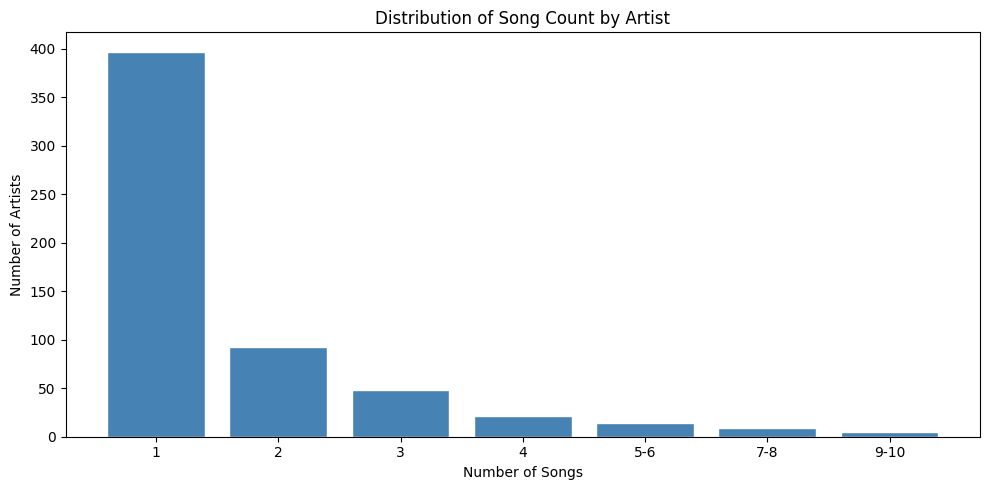

In [6]:
# Bin counts: 1-4 stay individual, 5-6, 7-8, 9-10 merged
def bin_count(x):
    if x <= 4:
        return str(x)
    elif x <= 6:
        return '5-6'
    elif x <= 8:
        return '7-8'
    elif x <= 10:
        return '9-10'
    else:
        return '11+'

df_artists['Bin'] = df_artists['Count'].apply(bin_count)

bin_order = ['1', '2', '3', '4', '5-6', '7-8', '9-10']
freq = df_artists['Bin'].value_counts().reindex(bin_order, fill_value=0)

plt.figure(figsize=(10, 5))
plt.bar(freq.index, freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Number of Songs')
plt.ylabel('Number of Artists')
plt.title('Distribution of Song Count by Artist')
plt.tight_layout()
plt.show()

In [7]:
# Plot for each playlist
def plot_artist_distribution(playlist):
    df_playlist = df_artists_by_playlist[df_artists_by_playlist['Playlist'] == playlist]
    df_playlist['Bin'] = df_playlist['Count'].apply(bin_count)
    freq = df_playlist['Bin'].value_counts().reindex(bin_order, fill_value=0)
    
    plt.figure(figsize=(10, 5))
    plt.bar(freq.index, freq.values, color='steelblue', edgecolor='white')
    plt.xlabel('Number of Songs')
    plt.ylabel('Number of Artists')
    plt.title(f'Distribution of Song Count by Artist in {playlist} Playlist')
    plt.tight_layout()
    plt.show()


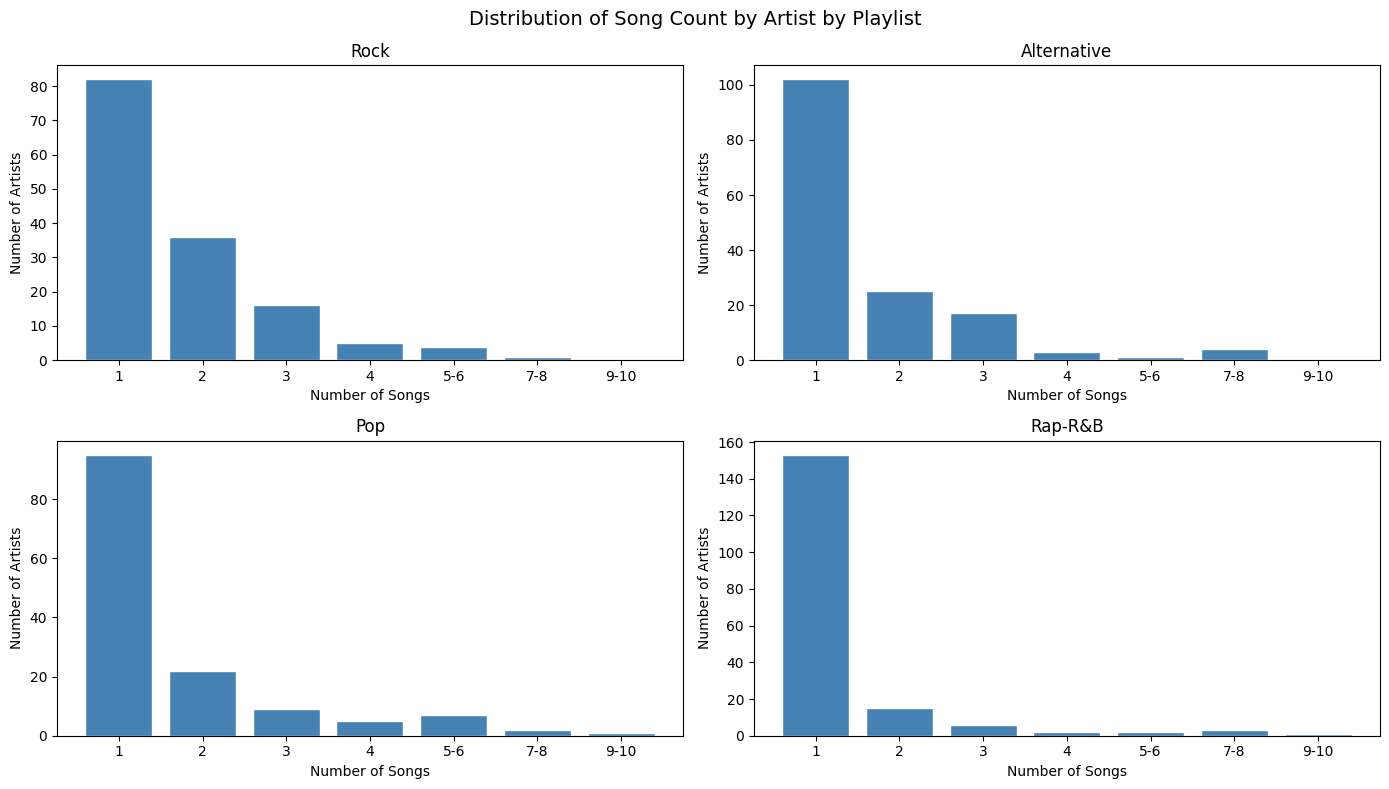

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

playlists = ['Rock', 'Alternative', 'Pop', 'Rap-R&B']

for ax, playlist in zip(axes, playlists):
    df_playlist = df_artists_by_playlist[df_artists_by_playlist['Playlist'] == playlist]
    df_playlist = df_playlist.copy()
    df_playlist['Bin'] = df_playlist['Count'].apply(bin_count)
    freq = df_playlist['Bin'].value_counts().reindex(bin_order, fill_value=0)
    ax.bar(freq.index, freq.values, color='steelblue', edgecolor='white')
    ax.set_xlabel('Number of Songs')
    ax.set_ylabel('Number of Artists')
    ax.set_title(f'{playlist}')

fig.suptitle('Distribution of Song Count by Artist by Playlist', fontsize=14)
plt.tight_layout()
plt.show()

### Album Year

In [9]:
# Bin album release years into decades
def bin_decade(year):
    if pd.isna(year):
        return 'Unknown'
    year = int(year)
    if year < 1970:
        return '1960s'
    elif year < 1980:
        return '1970s'
    elif year < 1990:
        return '1980s'
    elif year < 2000:
        return '1990s'
    elif year < 2010:
        return '2000s'
    elif year < 2020:
        return '2010s'
    else:
        return '2020s'

decade_order = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s', 'Unknown']

df_library['Decade'] = df_library['album_year'].apply(bin_decade)
decade_counts = df_library['Decade'].value_counts().reindex(decade_order, fill_value=0)
decade_counts

Decade
1960s        5
1970s       37
1980s       64
1990s       87
2000s      298
2010s      384
2020s      125
Unknown      0
Name: count, dtype: int64

In [10]:
# Get decade counts by playlist
decade_counts_by_playlist = (
    df_library.groupby(['Playlist', 'Decade'])
    .size()
    .reindex(pd.MultiIndex.from_product([['Alternative', 'Pop', 'Rap-R&B', 'Rock'], decade_order], names=['Playlist', 'Decade']), fill_value=0)
    .reset_index(name='Count')
)

# Pivot dataframe
decade_pivot = decade_counts_by_playlist.pivot(index='Playlist', columns='Decade', values='Count')
decade_pivot.loc['Total'] = decade_pivot.sum()
decade_pivot

Decade,1960s,1970s,1980s,1990s,2000s,2010s,2020s,Unknown
Playlist,,,,,,,,
Alternative,0,0,0,0,0,190,60,0
Pop,1,4,19,43,121,44,18,0
Rap-R&B,0,0,5,25,110,84,26,0
Rock,4,33,40,19,67,66,21,0
Total,5,37,64,87,298,384,125,0


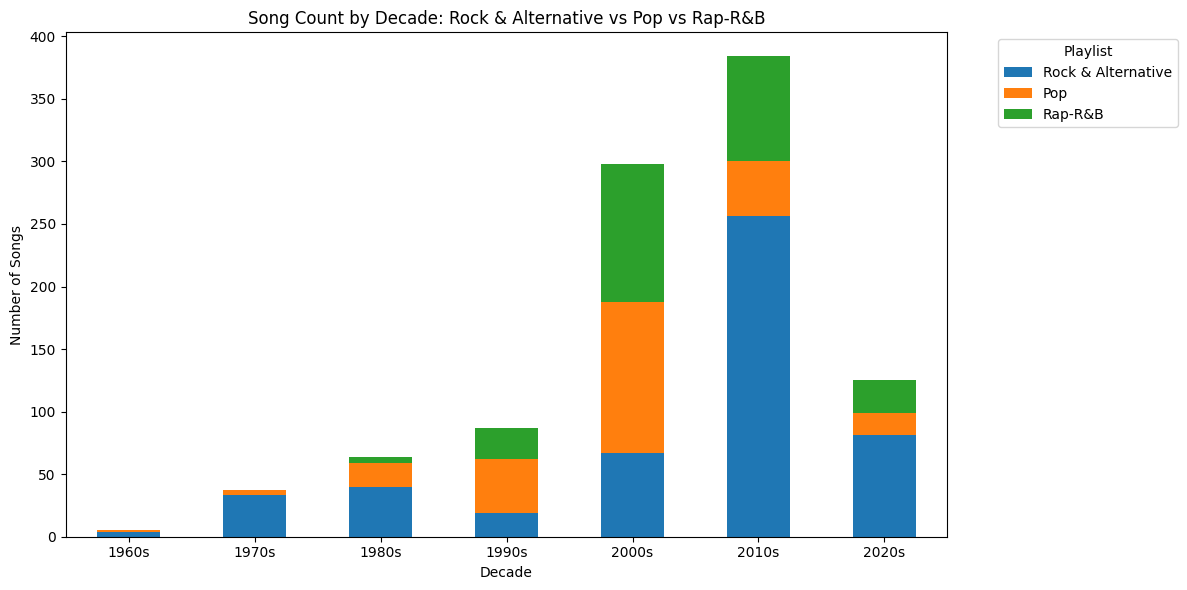

In [11]:
decade_order_plot = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

plot_data = decade_pivot.loc[['Rock', 'Alternative', 'Pop', 'Rap-R&B'], decade_order_plot].copy()
plot_data.loc['Rock & Alternative'] = plot_data.loc['Rock'] + plot_data.loc['Alternative']
plot_data = plot_data.loc[['Rock & Alternative', 'Pop', 'Rap-R&B'], decade_order_plot]

plot_data.T.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Decade')
plt.ylabel('Number of Songs')
plt.title('Song Count by Decade: Rock & Alternative vs Pop vs Rap-R&B')
plt.legend(title='Playlist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Analyze songs from 1995-2005 (CD era)
df_cds = df_library[(df_library['album_year'] >= 1995) & (df_library['album_year'] < 2006)]
print(f"Number of songs from 1995-2005: {len(df_cds)}")
print('Average number of songs per year in 1995-2005:', round(len(df_cds) / 11, 1))
print('Range of songs per year:', df_cds['album_year'].value_counts().min(), '-', df_cds['album_year'].value_counts().max())

# Analyze songs from 2006-2014 (iTunes era)
df_itunes = df_library[(df_library['album_year'] >= 2006) & (df_library['album_year'] < 2015)]
print(f"\nNumber of songs from 2006-2014: {len(df_itunes)}")
print('Average number of songs per year in 2006-2014:', round(len(df_itunes) / 9, 1))
print('Range of songs per year:', df_itunes['album_year'].value_counts().min(), '-', df_itunes['album_year'].value_counts().max())

# Analyze songs from 2015-2025 (Spotify era)
df_spotify = df_library[(df_library['album_year'] >= 2015) & (df_library['album_year'] < 2026)]
print(f"\nNumber of songs from 2015-2025: {len(df_spotify)}")
print('Average number of songs per year in 2020s:', round(len(df_spotify) / 11, 1))
print('Range of songs per year:', df_spotify['album_year'].value_counts().min(), '-', df_spotify['album_year'].value_counts().max())


Number of songs from 1995-2005: 229
Average number of songs per year in 1995-2005: 20.8
Range of songs per year: 7 - 37

Number of songs from 2006-2014: 290
Average number of songs per year in 2006-2014: 32.2
Range of songs per year: 27 - 46

Number of songs from 2015-2025: 351
Average number of songs per year in 2020s: 31.9
Range of songs per year: 9 - 58


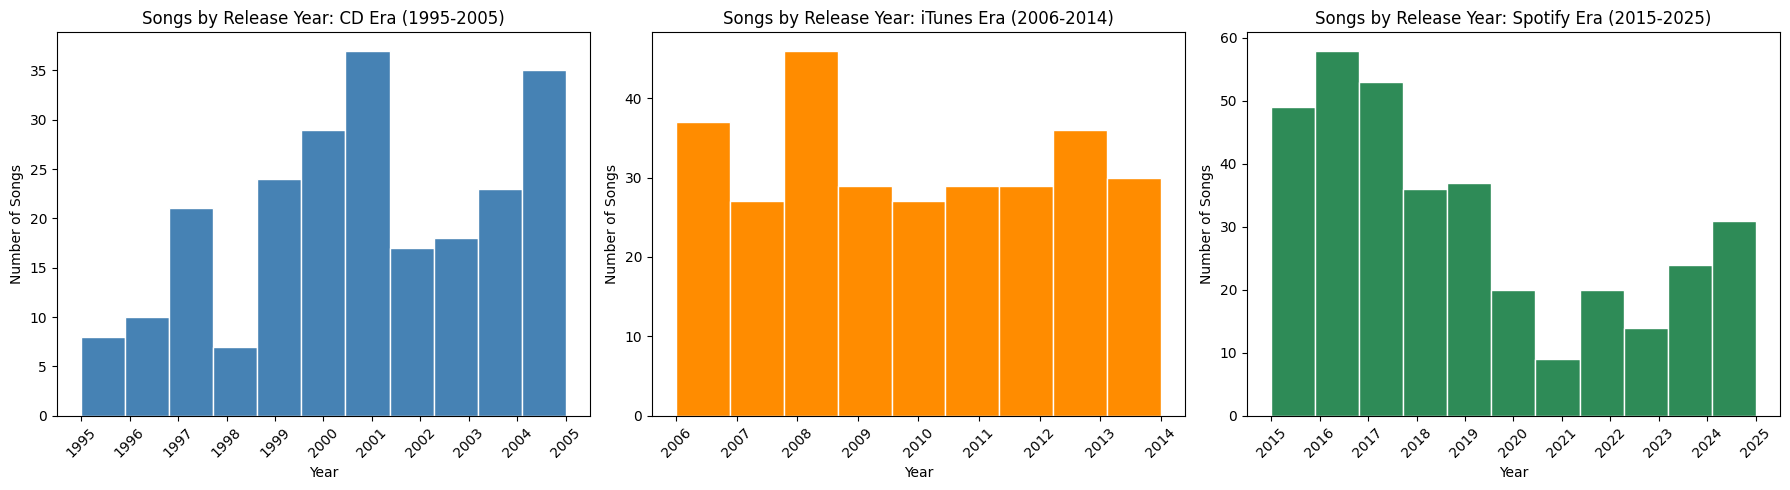

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

eras = [
    (df_cds, range(1995, 2006), 'Songs by Release Year: CD Era (1995-2005)', 'steelblue'),
    (df_itunes, range(2006, 2015), 'Songs by Release Year: iTunes Era (2006-2014)', 'darkorange'),
    (df_spotify, range(2015, 2026), 'Songs by Release Year: Spotify Era (2015-2025)', 'seagreen'),
]

for ax, (df, xticks, title, color) in zip(axes, eras):
    ax.hist(df['album_year'], bins=len(xticks), color=color, edgecolor='white')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Songs')
    ax.set_title(title)
    ax.set_xticks(xticks)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Popularity

In [14]:
df_library['Popularity'].describe()

count    1000.000000
mean       58.351000
std        19.275771
min         0.000000
25%        48.000000
50%        62.000000
75%        72.000000
max        98.000000
Name: Popularity, dtype: float64

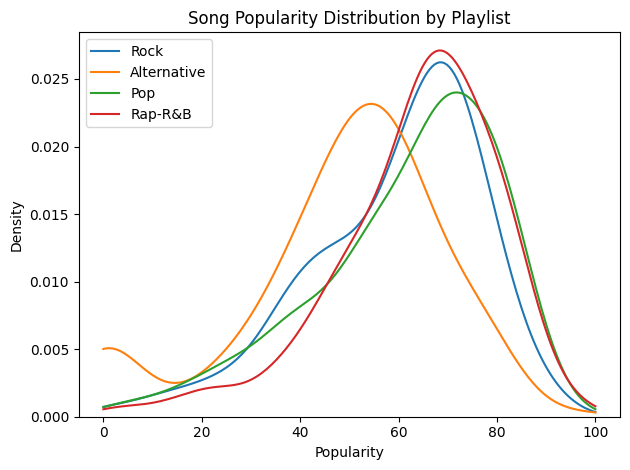

In [15]:
for playlist in playlists:
    df_playlist = df_library[df_library['Playlist'] == playlist]
    sns.kdeplot(df_playlist['Popularity'], label=playlist, clip=(0, 100))

plt.xlabel('Popularity')
plt.ylabel('Density')
plt.title('Song Popularity Distribution by Playlist')
plt.legend()
plt.tight_layout()
plt.show()